# Evaluación Parcial N°3 - Google Play Store

## 🎯 Objetivo
Consolidar en un único notebook el trabajo analítico de la Evaluación 2 y ampliarlo con los componentes de la Evaluación 3: documentación técnica reproducible, validación del pipeline de datos, visualizaciones avanzadas y un dashboard interactivo construido con Dash.

**Pregunta de trabajo:** ¿qué patrones del ecosistema Google Play permiten describir, segmentar y predecir si una aplicación será gratuita o de pago, y cómo comunicar estos resultados mediante un dashboard profesional?

## 🧱 Estructura esperada del proyecto

```text
proyecto-googleplay-ev3/
│
├── data/
│   └── raw/
│       └── googleplaystore.csv
│
├── docs/
│   └── README.md
│
└── Evaluacion_3_GooglePlay_Pipeline.ipynb
```

Este notebook está pensado para funcionar dentro de esa estructura mínima, sin Docker, sin API propia y usando únicamente las librerías autorizadas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import dash
from dash import Dash, dcc, html, dash_table
from dash.dependencies import Input, Output

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)

## 🔍 Exploración y Diagnóstico (EDA)

Primero se carga el dataset original y se audita su estructura. Esta fase es crítica porque el archivo de Google Play suele contener variables numéricas almacenadas como texto, valores faltantes y duplicados por aplicación.

In [2]:
from pathlib import Path

possible_paths = [
    Path("data/raw/googleplaystore.csv"),
    Path("/content/proyecto-googleplay-ev3/data/raw/googleplaystore.csv"),
    Path("googleplaystore.csv"),
    Path("googleplaystore-2.csv")
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("No se encontró googleplaystore.csv en las rutas esperadas.")


df_original = pd.read_csv(data_path)
df = df_original.copy()

print(f"Ruta utilizada: {data_path}")
print(f"Shape original: {df.shape}")
display(df.head())
display(df.info())

Ruta utilizada: data\raw\googleplaystore.csv
Shape original: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


None

In [3]:
resumen_nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str)
}).sort_values("nulos", ascending=False)

print("Duplicados por App:", df.duplicated(subset=["App"]).sum())
display(resumen_nulos)

Duplicados por App: 1181


,nulos,porcentaje_nulos,dtype
Rating,1474,13.60,float64
Current Ver,8,0.07,str
Android Ver,3,0.03,str
Content Rating,1,0.01,str
Type,1,0.01,str
Size,0,0.00,str
Reviews,0,0.00,str
Category,0,0.00,str
App,0,0.00,str
Price,0,0.00,str


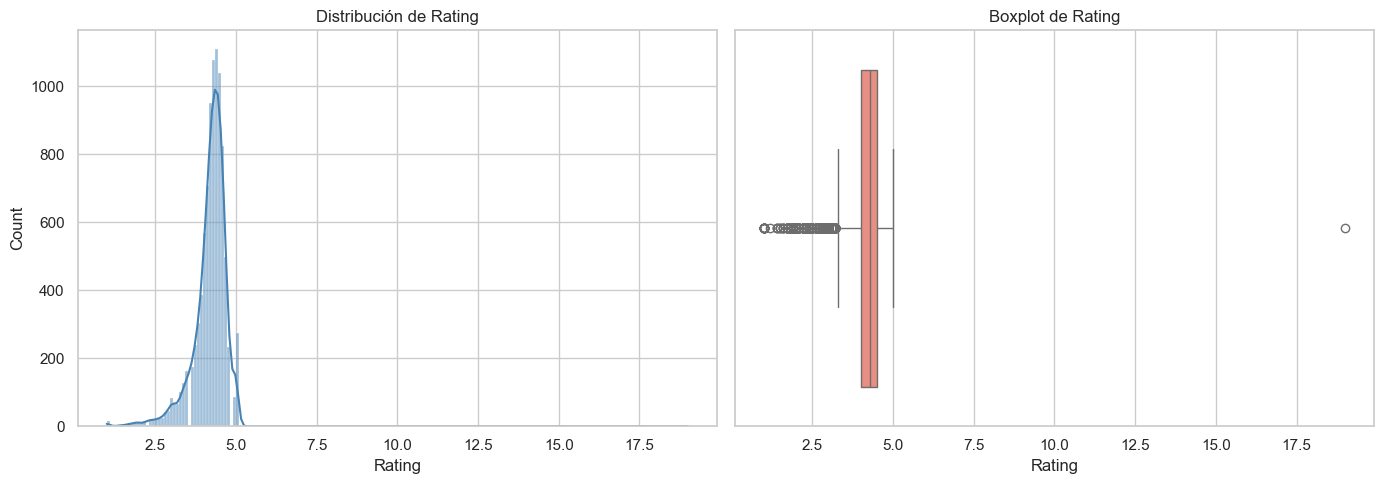

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Rating"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de Rating")
axes[0].set_xlabel("Rating")

sns.boxplot(x=df["Rating"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot de Rating")
axes[1].set_xlabel("Rating")

plt.tight_layout()
plt.show()

**Justificación EDA:** se inspecciona `Rating` con histograma y boxplot porque es una variable continua central para el análisis de calidad percibida, y además permite evaluar asimetría y outliers antes de definir la estrategia de limpieza.

## 🛠️ Preprocesamiento

Se aplica una estrategia de limpieza orientada a reproducibilidad y robustez. La mediana se utiliza para imputar `Rating` porque es menos sensible a valores extremos; las columnas numéricas almacenadas como texto se convierten con reglas explícitas; y se eliminan registros con nulos críticos que afectarían el modelado.

In [5]:
# 1. Eliminar duplicados por nombre de aplicación
df = df.drop_duplicates(subset=["App"]).copy()

# 2. Imputar Rating con mediana
df["Rating"] = df["Rating"].fillna(df["Rating"].median())

# 3. Conversión de columnas numéricas

def parse_installs(value: str) -> float:
    value = str(value).replace(",", "").replace("+", "").strip()
    return pd.to_numeric(value, errors="coerce")


def parse_price(value: str) -> float:
    value = str(value).replace("$", "").strip()
    return pd.to_numeric(value, errors="coerce")


def parse_size(value: str) -> float:
    value = str(value).strip()
    if value == "Varies with device":
        return np.nan
    if value.endswith("M"):
        return float(value[:-1]) * 1_000_000
    if value.endswith("k"):
        return float(value[:-1]) * 1_000
    return np.nan


df["Installs"] = df["Installs"].apply(parse_installs)
df["Price"] = df["Price"].apply(parse_price)
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")
df["Size"] = df["Size"].astype(str).apply(parse_size)
df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

# 4. Imputación robusta de Size con mediana
df["Size"] = df["Size"].fillna(df["Size"].median())

# 5. Normalización de texto
df["Category"] = df["Category"].astype(str).str.strip().str.upper()
df["Type"] = df["Type"].astype(str).str.strip()

# 6. Eliminación de nulos críticos
critical_cols = ["Installs", "Price", "Reviews", "Type", "Content Rating", "Current Ver", "Android Ver"]
df = df.dropna(subset=critical_cols).copy()

# 7. Regla de consistencia
mask_inconsistent = (df["Type"].eq("Free")) & (df["Price"] > 0)
df = df.loc[~mask_inconsistent].copy()

print("Shape luego de limpieza básica:", df.shape)
display(df.head())

Shape luego de limpieza básica: (9648, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19000000.0,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14000000.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8700000.0,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25000000.0,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2800000.0,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [6]:
# Detección de outliers en Rating por IQR
q1 = df["Rating"].quantile(0.25)
q3 = df["Rating"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

before_rows = len(df)
df = df[(df["Rating"] >= lower) & (df["Rating"] <= upper)].copy()
after_rows = len(df)

print(f"Filas eliminadas por IQR en Rating: {before_rows - after_rows}")
print(f"Límites IQR: [{lower:.2f}, {upper:.2f}]")
print(f"Shape final preprocesado: {df.shape}")

Filas eliminadas por IQR en Rating: 491
Límites IQR: [3.25, 5.25]
Shape final preprocesado: (9157, 13)


## 📊 Análisis descriptivo posterior a la limpieza

Con el dataset limpio, se revisan distribuciones clave y relaciones entre variables. Esta etapa permite verificar si las transformaciones preservaron el sentido de negocio de los datos.

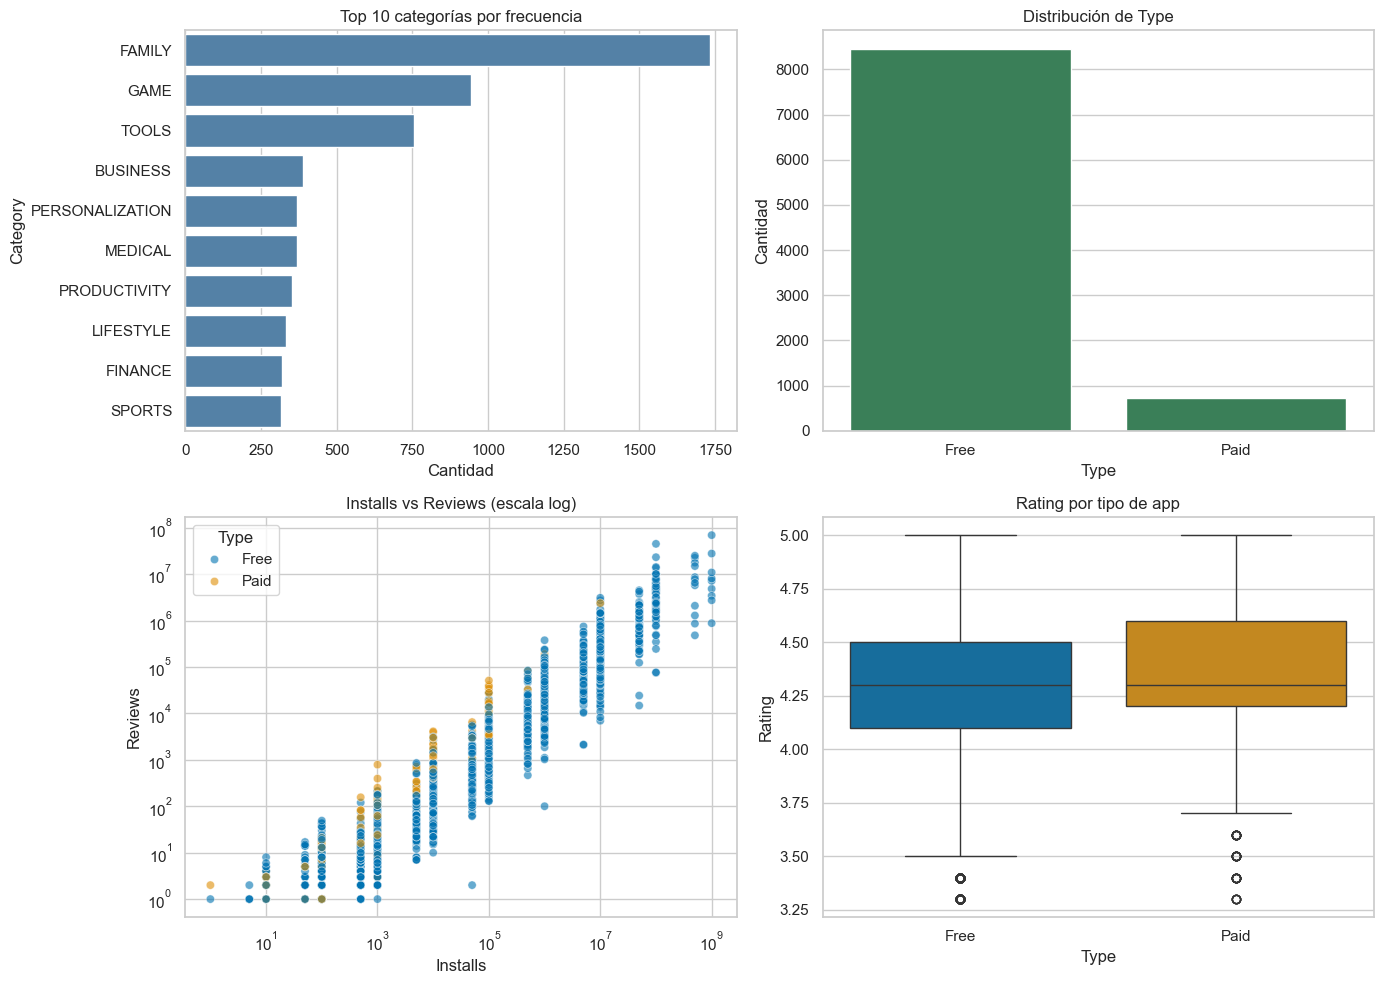

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, y="Category", order=df["Category"].value_counts().head(10).index, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Top 10 categorías por frecuencia")
axes[0, 0].set_xlabel("Cantidad")
axes[0, 0].set_ylabel("Category")

sns.countplot(data=df, x="Type", ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Distribución de Type")
axes[0, 1].set_xlabel("Type")
axes[0, 1].set_ylabel("Cantidad")

sns.scatterplot(data=df.sample(min(len(df), 3000), random_state=RANDOM_STATE), x="Installs", y="Reviews", hue="Type", alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Installs vs Reviews (escala log)")

sns.boxplot(data=df, x="Type", y="Rating", ax=axes[1, 1], palette="colorblind")
axes[1, 1].set_title("Rating por tipo de app")

plt.tight_layout()
plt.show()

,Rating,Reviews,Size,Installs,Price
Rating,1.000,0.033,0.020,-0.044,0.070
Reviews,0.033,1.000,0.301,0.968,-0.154
Size,0.020,0.301,1.000,0.282,-0.041
Installs,-0.044,0.968,0.282,1.000,-0.233
Price,0.070,-0.154,-0.041,-0.233,1.000


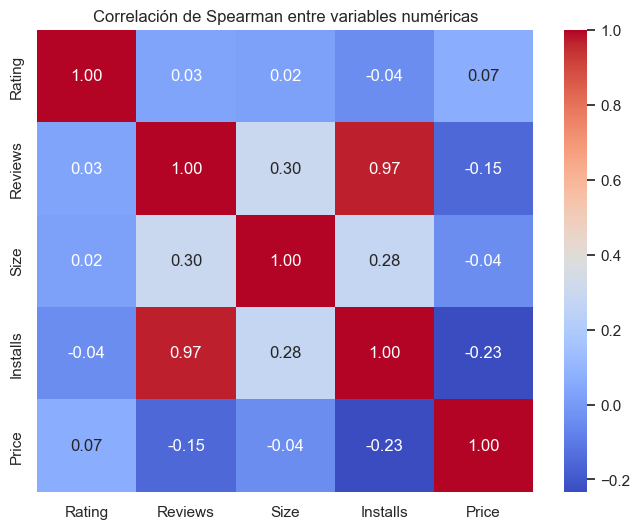

In [8]:
corr_df = df[["Rating", "Reviews", "Size", "Installs", "Price"]].copy()
correlation = corr_df.corr(method="spearman")

display(correlation.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación de Spearman entre variables numéricas")
plt.show()

**Conclusión EDA:** `Installs` y `Reviews` tienden a relacionarse fuertemente, lo que es esperable porque mayor base instalada suele generar más reseñas. `Price` presenta una distribución muy sesgada hacia cero, por lo que su interpretación debe hacerse con cuidado en visualizaciones y modelos.

## 🛠️ Ingeniería de variables

Para machine learning, se construye una variable objetivo binaria y se generan predictores numéricos y categóricos. Se usa OneHotEncoder para evitar introducir relaciones ordinales artificiales en `Category` y `Content Rating`.

In [9]:
df["Type_encoded"] = (df["Type"] == "Paid").astype(int)

feature_cols_num = ["Rating", "Reviews", "Size", "Installs", "Price"]
feature_cols_cat = ["Category", "Content Rating"]
target_col = "Type_encoded"

X = df[feature_cols_num + feature_cols_cat].copy()
y = df[target_col].copy()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, feature_cols_num),
    ("cat", categorical_transformer, feature_cols_cat)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(y.value_counts(normalize=True).rename("proportion"))

Train shape: (7325, 7)
Test shape: (1832, 7)
Type_encoded
0    0.921699
1    0.078301
Name: proportion, dtype: float64


## 🤖 Modelado

Se proponen tres enfoques con distinta complejidad: una Regresión Logística como baseline interpretable, Random Forest como modelo no lineal robusto y Gradient Boosting como alternativa más expresiva. Todos se encapsulan en pipelines para evitar data leakage.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, class_weight="balanced"))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "AUC_ROC": roc_auc_score(y_test, y_proba)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("F1_macro", ascending=False)
display(results_df.round(4))

,Modelo,Accuracy,F1_macro,AUC_ROC
1,Random Forest,1.0000,1.0000,1.0000
2,Gradient Boosting,1.0000,1.0000,1.0000
0,Logistic Regression,0.9733,0.8895,0.9938


In [11]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = fitted_models[best_model_name]

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else y_pred_best

cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(cm, index=["Real_Free", "Real_Paid"], columns=["Pred_Free", "Pred_Paid"])

display(cm_df)
print(best_model_name)
print(classification_report(y_test, y_pred_best, target_names=["Free", "Paid"]))

,Pred_Free,Pred_Paid
Real_Free,1689,0
Real_Paid,0,143


Random Forest
              precision    recall  f1-score   support

        Free       1.00      1.00      1.00      1689
        Paid       1.00      1.00      1.00       143

    accuracy                           1.00      1832
   macro avg       1.00      1.00      1.00      1832
weighted avg       1.00      1.00      1.00      1832



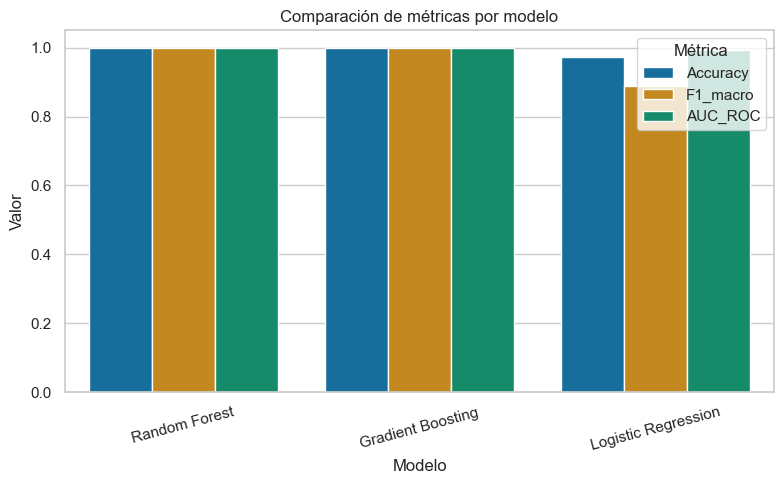

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor"), x="Modelo", y="Valor", hue="Métrica")
plt.title("Comparación de métricas por modelo")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 📊 Clustering

Como complemento no supervisado, se segmentan aplicaciones según popularidad y tamaño. Se usa K-Means porque las variables numéricas principales permiten una geometría razonablemente compacta tras escalar y aplicar transformaciones logarítmicas a las magnitudes más sesgadas.

In [13]:
cluster_df = df[["Rating", "Reviews", "Size", "Installs"]].copy()
cluster_df["Reviews"] = np.log1p(cluster_df["Reviews"])
cluster_df["Installs"] = np.log1p(cluster_df["Installs"])

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_cluster)
df["Cluster"] = clusters

sil = silhouette_score(X_cluster, clusters)
print(f"Silhouette Score: {sil:.4f}")

display(df.groupby("Cluster")[["Rating", "Reviews", "Size", "Installs", "Price"]].mean().round(2))

Silhouette Score: 0.3641


,Rating,Reviews,Size,Installs,Price
Cluster,,,,,
0,4.38,465886.23,14427182.24,18399852.49,0.17
1,4.44,68.73,12079603.29,3814.38,1.58
2,3.78,7454.67,13522737.72,852929.53,2.54
3,4.29,511807.23,65128415.30,12353655.87,0.27


In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_proj = pca.fit_transform(X_cluster)
plot_df = pd.DataFrame({
    "PC1": cluster_proj[:, 0],
    "PC2": cluster_proj[:, 1],
    "Cluster": df["Cluster"].astype(str),
    "Type": df["Type"].values
})

fig = px.scatter(
    plot_df.sample(min(len(plot_df), 4000), random_state=RANDOM_STATE),
    x="PC1", y="PC2", color="Cluster", symbol="Type",
    title="Clusters de apps proyectados con PCA"
)
fig.update_layout(template="plotly_white")
fig.show()

## 📋 Evaluación e integridad del dataset

Además del modelado, la Evaluación 3 necesita evidencias claras de calidad del proceso. Por eso se incorpora una auditoría de integridad con reglas de negocio simples y verificables.

In [16]:
def auditar_dataset(df_input: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df_input.columns:
        rows.append({
            "Columna": col,
            "Tipo": str(df_input[col].dtype),
            "Nulos": int(df_input[col].isna().sum()),
            "% Nulos": round(df_input[col].isna().mean() * 100, 2),
            "Únicos": int(df_input[col].nunique(dropna=True)),
            "Estado": "OK" if df_input[col].isna().sum() == 0 else "REVISAR"
        })
    return pd.DataFrame(rows)


def validar_rangos(df_input: pd.DataFrame) -> pd.DataFrame:
    checks = [
        ("Rating entre 1 y 5", df_input["Rating"].between(1, 5)),
        ("Price no negativo", df_input["Price"] >= 0),
        ("Installs no negativo", df_input["Installs"] >= 0),
        ("Reviews no negativo", df_input["Reviews"] >= 0),
    ]
    rows = []
    total = len(df_input)
    for name, condition in checks:
        ok = int(condition.sum())
        fail = int(total - ok)
        rows.append({
            "Regla": name,
            "Cumplen": ok,
            "Violan": fail,
            "% Cumplimiento": round(ok / total * 100, 2),
            "Estado": "PASS" if fail == 0 else "FAIL"
        })
    return pd.DataFrame(rows)


audit_report = auditar_dataset(df)
range_report = validar_rangos(df)
consistency_report = df.loc[(df["Type"] == "Free") & (df["Price"] > 0), ["App", "Type", "Price"]]

display(audit_report)
display(range_report)
display(consistency_report.head())

integrity_score = (range_report["Estado"] == "PASS").mean() * 100
print(f"Score general de integridad: {integrity_score:.1f}")

,Columna,Tipo,Nulos,% Nulos,Únicos,Estado
0,App,str,0,0.0,9157,OK
1,Category,str,0,0.0,33,OK
2,Rating,float64,0,0.0,18,OK
3,Reviews,float64,0,0.0,5224,OK
4,Size,float64,0,0.0,437,OK
5,Installs,float64,0,0.0,20,OK
6,Type,str,0,0.0,2,OK
7,Price,float64,0,0.0,90,OK
8,Content Rating,str,0,0.0,6,OK
9,Genres,str,0,0.0,118,OK


,Regla,Cumplen,Violan,% Cumplimiento,Estado
0,Rating entre 1 y 5,9157,0,100.0,PASS
1,Price no negativo,9157,0,100.0,PASS
2,Installs no negativo,9157,0,100.0,PASS
3,Reviews no negativo,9157,0,100.0,PASS


,App,Type,Price


Score general de integridad: 100.0


## 📝 Informe Final

### Hallazgos clave
- El ecosistema está fuertemente dominado por apps gratuitas, lo que introduce desbalance de clases en la predicción.
- Las variables de popularidad, especialmente `Installs` y `Reviews`, concentran gran parte de la señal analítica.
- El clustering permite distinguir perfiles de apps masivas, nicho y tamaño intermedio.

### Decisiones técnicas justificadas
- Se utilizó imputación por mediana en variables sesgadas.
- Se usó OneHotEncoder para variables categóricas nominales.
- Se encapsuló todo en un solo notebook para cumplir el formato de entrega.
- Dash se integró dentro del notebook para mantener una solución reproducible y profesional.

### Resultados de negocio
- El modelo supervisado entrega una base para apoyar decisiones de monetización (`Free` vs `Paid`).
- El dashboard facilita comunicar resultados a audiencias ejecutivas y técnicas con filtros y KPIs.

### Próximos pasos
- Incorporar ingeniería de atributos temporales desde `Last Updated`.
- Evaluar técnicas para clases desbalanceadas.
- Desplegar el dashboard en un servicio web cuando el curso lo permita.

## ⚠️ Consideraciones

- El dataset contiene sesgos estructurales del marketplace y no representa causalidad directa.
- La calidad del modelo depende de variables limitadas; no se usan descripciones textuales ni señales externas.
- Dash está incluido en el notebook como evidencia funcional, pero su ejecución final depende del entorno donde se abra el archivo.
- No se utiliza Docker ni API REST, porque el alcance del proyecto se ajusta a `data/`, `docs/` y un notebook principal único.